# GPU Frame Potential — first test

This notebook walks through the GPU implementation step by step, from installation verification to a CPU vs GPU timing comparison.

---
## Step 0 — Installation

### 0a. Check your CUDA version first

Run this in a **terminal** (not in Jupyter):
```bash
nvidia-smi
```
Look for `xpu Version: XX.X` in the top-right corner of the output.

### 0b. Install PyTorch with the right cuda build

```bash
# CUDA 12.1 — most common on modern systems (RTX 30xx / 40xx)
pip install torch --index-url https://download.pytorch.org/whl/cu121

# CUDA 11.8 — older systems
pip install torch --index-url https://download.pytorch.org/whl/cu118

# No GPU (CPU-only fallback — code still runs, just no speedup)
pip install torch --index-url https://download.pytorch.org/whl/cpu
```

> **Important**: do NOT just `pip install torch` without the `--index-url` flag.  
> That installs the CPU-only build by default on most systems.

In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="The detected GPU.*is not officially supported by PyTorch XPU"
)

In [3]:
# ── Cell 0: verify the installation ──────────────────────────────────────────
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"xpu available   : {torch.xpu.is_available()}")

if torch.xpu.is_available():
    props = torch.xpu.get_device_properties(0)
    print(f"GPU             : {props.name}")
    print(f"VRAM            : {props.total_memory / 1024**3:.1f} GB")
    print(f"xpu version     : {torch.version.xpu}")
else:
    print("No GPU detected — all cells will run on CPU (correct but slow)")

PyTorch version : 2.11.0+xpu
xpu available   : True
GPU             : Intel(R) Iris(R) Xe Graphics
VRAM            : 28.7 GB
xpu version     : 20250302


---
## Step 1 — Imports

In [4]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit.library import efficient_su2

# GPU implementation (this file must be in the same folder)
from frame_potential_gpu import (
    get_device,
    recommended_batch_size,
    sample_unitaries_cpu,
    to_gpu,
    frame_potential_gpu,
    haar_frame_potential,
    compute_frame_potential_gpu,
)

# Original CPU implementation for comparison
from frame_potential import frame_potential as frame_potential_cpu

device = get_device(verbose=True)
print("\nAll imports OK ✓")

GPU found : Intel(R) Iris(R) Xe Graphics  (Intel XPU)
VRAM      : 28.7 GB

All imports OK ✓


---
## Step 2 — Understand the data flow

There are three distinct stages. Each runs in a different place:

```
CPU (Qiskit)          CPU→GPU (transfer)       GPU (PyTorch)
──────────────────    ─────────────────────    ──────────────────────────
sample_unitaries_cpu  to_gpu(Us_cpu, device)   frame_potential_gpu(Us_gpu)
returns np.array      returns torch.Tensor      returns float
(N, d, d) complex128  (N, d, d) complex64
```

The transfer happens **once**. All N² pair computations then happen on the GPU.

In [5]:
# ── Circuit setup ─────────────────────────────────────────────────────────────
N_QUBITS  = 4
N_SAMPLES = 300
T_ORDER   = 2
SEED      = 42

circuit = efficient_su2(N_QUBITS, reps=2, entanglement='linear')
d = 2**N_QUBITS

print(f"Circuit : {N_QUBITS} qubits, {circuit.num_parameters} parameters, d={d}")

# Auto batch size
if device.type == 'xpu':
    vram_gb = torch.xpu.get_device_properties(device).total_memory / 1024**3
    B = recommended_batch_size(d, vram_gb, torch.complex64, N_SAMPLES)
    print(f"Recommended batch size : {B}")
else:
    B = N_SAMPLES
    print(f"CPU mode — batch size = {B} (full N)")

Circuit : 4 qubits, 24 parameters, d=16
Recommended batch size : 300


---
## Step 3 — Stage 1: sample unitaries on the CPU

In [6]:
rng = np.random.default_rng(SEED)

t0 = time.perf_counter()
Us_cpu_A = sample_unitaries_cpu(circuit, N_SAMPLES, rng=rng, verbose=True)
Us_cpu_B = sample_unitaries_cpu(circuit, N_SAMPLES, rng=rng, verbose=True)
t_sample = time.perf_counter() - t0

print(f"\nShape  : {Us_cpu_A.shape}")
print(f"dtype  : {Us_cpu_A.dtype}")
print(f"Size   : {Us_cpu_A.nbytes / 1024**2:.2f} MB")
print(f"Time   : {t_sample:.2f}s")

# Sanity check: first unitary should be unitary
U0  = Us_cpu_A[0]
err = np.max(np.abs(U0.conj().T @ U0 - np.eye(d)))
print(f"\nUnitarity check ||U†U - I||_max = {err:.2e}  ({'✓' if err < 1e-9 else '✗'})")

Sampling on CPU: 100%|██████████| 300/300 [00:00<00:00, 719.99it/s]


Shape  : (300, 16, 16)
dtype  : complex128
Size   : 1.17 MB
Time   : 0.84s

Unitarity check ||U†U - I||_max = 4.44e-16  (✓)


---
## Step 4 — Stage 2: transfer to GPU

This is where the numpy complex128 array becomes a PyTorch complex64 tensor on the GPU.  
We do this **once** — not inside any loop.

In [7]:
t0 = time.perf_counter()
Us_gpu_A = to_gpu(Us_cpu_A, device, dtype=torch.complex64)
Us_gpu_B = to_gpu(Us_cpu_B, device, dtype=torch.complex64)
if device.type == 'xpu':
    torch.xpu.synchronize()   # wait for async transfer to complete before timing
t_transfer = time.perf_counter() - t0

print(f"Tensor device  : {Us_gpu_A.device}")
print(f"Tensor dtype   : {Us_gpu_A.dtype}")
print(f"Tensor shape   : {Us_gpu_A.shape}")
print(f"VRAM used      : {Us_gpu_A.element_size() * Us_gpu_A.nelement() / 1024**2:.2f} MB")
print(f"Transfer time  : {t_transfer*1000:.1f} ms")

Tensor device  : xpu:0
Tensor dtype   : torch.complex64
Tensor shape   : torch.Size([300, 16, 16])
VRAM used      : 0.59 MB
Transfer time  : 9.0 ms


---
## Step 5 — Stage 3: compute frame potential on the GPU

Let's first run it manually so you can see each sub-step clearly.

In [8]:
# ── Manual step-through for one block (i=0, j=0) ─────────────────────────────

B_demo = min(8, N_SAMPLES)   # small block for illustration

Ai = Us_gpu_A[:B_demo].unsqueeze(1)    # (B, 1, d, d)
Bj = Us_gpu_B[:B_demo].unsqueeze(0)    # (1, B, d, d)

print(f"Ai shape : {Ai.shape}   (B, 1, d, d) — broadcast over j")
print(f"Bj shape : {Bj.shape}   (1, B, d, d) — broadcast over i")

# einsum contracts the p,q axes (matrix indices), keeps b,i axes (sample indices)
traces = torch.einsum("bipq,bjpq->bij", Ai.conj(), Bj)
print(f"\ntraces shape : {traces.shape}   — one complex trace per pair")
print(f"traces dtype : {traces.dtype}")

# The diagonal (i == j) should be Tr(U†U) = Tr(I) = d
diag_traces = torch.abs(torch.diagonal(traces[0], dim1=0, dim2=1))
print(f"\n|Tr(Uᵢ†Uᵢ)| for first 4 samples: {diag_traces[:4].tolist()}")
print(f"Expected: {d} (= Tr(I) for a {d}×{d} identity)")

# Contribution of this block to the total
block_contrib = torch.sum(torch.abs(traces) ** (2 * T_ORDER)).item()
print(f"\nBlock contribution : {block_contrib:.4f}")

Ai shape : torch.Size([8, 1, 16, 16])   (B, 1, d, d) — broadcast over j
Bj shape : torch.Size([1, 8, 16, 16])   (1, B, d, d) — broadcast over i

traces shape : torch.Size([8, 1, 8])   — one complex trace per pair
traces dtype : torch.complex64

|Tr(Uᵢ†Uᵢ)| for first 4 samples: [0.9453088641166687]
Expected: 16 (= Tr(I) for a 16×16 identity)

Block contribution : 148.4577


In [9]:
# ── Full computation ──────────────────────────────────────────────────────────
if device.type == 'xpu':
    torch.xpu.synchronize()
t0 = time.perf_counter()

result_gpu = frame_potential_gpu(Us_gpu_A,Us_gpu_B, t=T_ORDER, batch_size=B)
F_gpu = result_gpu["frame_potential"]

if device.type == 'xpu':
    torch.xpu.synchronize()
t_gpu = time.perf_counter() - t0

F_haar = haar_frame_potential(T_ORDER, d)

print(f"F^({T_ORDER}) GPU  = {F_gpu:.6f}")
print(f"F_Haar        = {F_haar:.6f}")
print(f"Ratio         = {F_gpu/F_haar:.4f}")
print(f"GPU time      = {t_gpu*1000:.1f} ms")

F^(2) GPU  = 2.500558
F_Haar        = 2.000000
Ratio         = 1.2503
GPU time      = 148.8 ms


/home/tardant/Bureau/Qiskit/architectures/Frame potential/notebooks/../frame_potential_gpu.py:229: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


---
## Step 6 — CPU vs GPU: verify numerical consistency

Both should give the same F^(t) (up to float32 rounding).

In [10]:
t0 = time.perf_counter()
result_cpu = frame_potential_cpu(Us_cpu_A,Us_cpu_B, T_ORDER, batch_size=256)
F_cpu = result_cpu["frame_potential"]

t_cpu = time.perf_counter() - t0

print(F_cpu)

print(f"F^({T_ORDER}) CPU (complex128) = {F_cpu:.6f}  — {t_cpu*1000:.1f} ms")
print(f"F^({T_ORDER}) GPU (complex64)  = {F_gpu:.6f}  — {t_gpu*1000:.1f} ms")
print(f"Absolute difference          = {abs(F_cpu - F_gpu):.2e}")
print()

# Compare the variances (should be close, but GPU is single precision so can be slightly higher)
V_cpu = result_cpu["variance"]
V_gpu = result_gpu["variance"]
print(f"Variance CPU (complex128) = {V_cpu:.2e}")
print(f"Variance GPU (complex64)  = {V_gpu:.2e}")
print(f"Variance ratio (GPU/CPU)  = {V_gpu/V_cpu:.2f}  (should be close to 1, but can be >1 due to single precision)")
print()

# The difference should be small (float32 rounding, ~1e-5 to 1e-7)
if abs(F_cpu - F_gpu) < 1e-3:
    print("✓ Results match (within float32 tolerance)")
else:
    print("✗ Large discrepancy — check dtype or batch_size")

2.5005577155818197
F^(2) CPU (complex128) = 2.500558  — 47.6 ms
F^(2) GPU (complex64)  = 2.500558  — 148.8 ms
Absolute difference          = 1.84e-07

Variance CPU (complex128) = 1.01e+02
Variance GPU (complex64)  = 1.01e+02
Variance ratio (GPU/CPU)  = 1.00  (should be close to 1, but can be >1 due to single precision)

✓ Results match (within float32 tolerance)


---
## Step 7 — Timing comparison across N values

This is where the GPU advantage becomes visible — especially for large N.

In [11]:
N_values = [50, 100, 200, 400, 800, 1000, 2000, 4000, 8000, 12000]

times_cpu = []
times_gpu = []

# Pre-sample the largest batch

t0 = time.perf_counter()
rng_ref  = np.random.default_rng(SEED)
Us_all_A   = sample_unitaries_cpu(circuit, max(N_values), rng=rng_ref, verbose=False)
Us_all_B   = sample_unitaries_cpu(circuit, max(N_values), rng=rng_ref, verbose=False)
print(f"Pre-sampling time: {time.perf_counter() - t0:.2f}s")

pre_time = [(time.perf_counter() - t0)* n/max(N_values) for n in N_values]

t0 = time.perf_counter()
Us_all_g_A = to_gpu(Us_all_A, device, dtype=torch.complex64)
Us_all_g_B = to_gpu(Us_all_B, device, dtype=torch.complex64)

print(f"Sending to gpu time: {time.perf_counter() - t0:.2f}s")

for N in N_values:
    Us_n_A   = Us_all_A[:N]
    Us_n_B   = Us_all_B[:N]
    Us_n_g_A = Us_all_g_A[:N]
    Us_n_g_B = Us_all_g_B[:N]

    # CPU
    t0 = time.perf_counter()
    frame_potential_cpu(Us_n_A,Us_n_B, t= T_ORDER, batch_size=256)
    times_cpu.append(time.perf_counter() - t0)

    # GPU
    if device.type == 'xpu':
        torch.xpu.synchronize()
    t0 = time.perf_counter()
    frame_potential_gpu(Us_n_g_A,Us_n_g_B, t= T_ORDER, batch_size=B)
    if device.type == 'xpu':
        torch.xpu.synchronize()
    times_gpu.append(time.perf_counter() - t0)

    speedup = times_cpu[-1] / times_gpu[-1]
    print(f"N={N:4d}  CPU={times_cpu[-1]*1000:7.1f}ms  GPU={times_gpu[-1]*1000:7.1f}ms  speedup={speedup:.1f}x")

Pre-sampling time: 28.37s
Sending to gpu time: 0.03s
N=  50  CPU=    2.8ms  GPU=    7.1ms  speedup=0.4x
N= 100  CPU=    5.6ms  GPU=    5.4ms  speedup=1.0x
N= 200  CPU=   17.1ms  GPU=    4.6ms  speedup=3.7x
N= 400  CPU=   64.1ms  GPU=    9.6ms  speedup=6.7x
N= 800  CPU=  252.3ms  GPU=   21.1ms  speedup=12.0x
N=1000  CPU=  367.8ms  GPU=   31.0ms  speedup=11.9x
N=2000  CPU= 1495.2ms  GPU=   64.5ms  speedup=23.2x
N=4000  CPU= 5795.7ms  GPU=  208.4ms  speedup=27.8x
N=8000  CPU=22939.7ms  GPU=  681.7ms  speedup=33.7x
N=12000  CPU=52970.9ms  GPU= 1508.5ms  speedup=35.1x


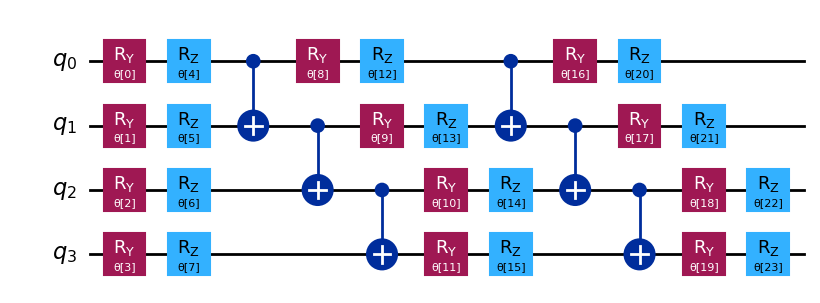

In [12]:
circuit.draw(output='mpl', fold=100)

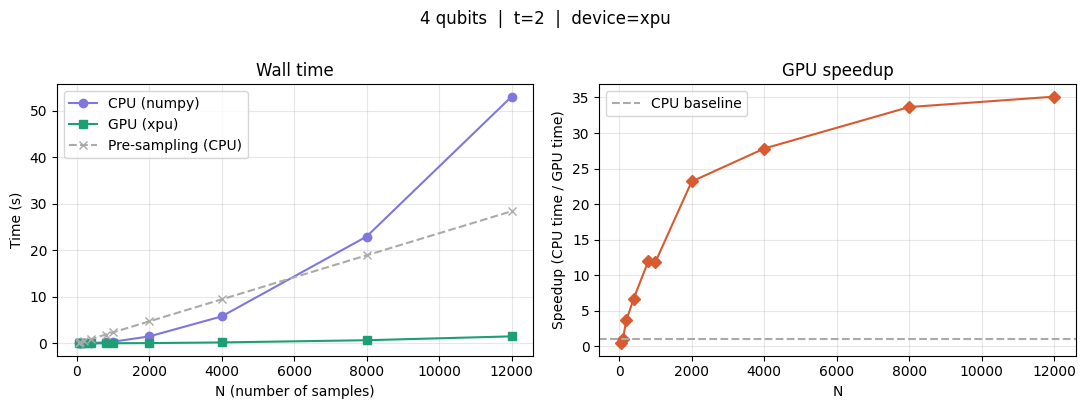

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(N_values, times_cpu, 'o-', color='#7f77dd', label='CPU (numpy)')
axes[0].plot(N_values, times_gpu, 's-', color='#1d9e75', label=f'GPU ({device.type})')
axes[0].plot(N_values, pre_time, 'x--', color='#aaaaaa', label='Pre-sampling (CPU)')
axes[0].set_xlabel('N (number of samples)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Wall time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

speedups = [c/g for c,g in zip(times_cpu, times_gpu)]
axes[1].plot(N_values, speedups, 'D-', color='#d85a30')
axes[1].axhline(1.0, color='#aaaaaa', linestyle='--', label='CPU baseline')
axes[1].set_xlabel('N')
axes[1].set_ylabel('Speedup (CPU time / GPU time)')
axes[1].set_title('GPU speedup')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{N_QUBITS} qubits  |  t={T_ORDER}  |  device={device}', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 8 — Full pipeline with one call

In [14]:
from circuit_generation import build_ansatz

In [15]:
circuit = build_ansatz("ghz_like", n_qubits=N_QUBITS, reps=1)

In [16]:
result = compute_frame_potential_gpu(
    circuit,
    t         = T_ORDER,
    n_samples = 1000,
    dtype     = torch.complex64,
    seed      = SEED,
    verbose   = True,
)
print(result)

GPU found : Intel(R) Iris(R) Xe Graphics  (Intel XPU)
VRAM      : 28.7 GB
Auto batch size : 1000  (VRAM=28.7GB, d=16)

n_qubits=4  d=16  N=1000  t=2
dtype=torch.complex64  batch_size=1000
──────────────────────────────────────────────────


Sampling on CPU: 100%|██████████| 1000/1000 [00:00<00:00, 1061.07it/s]


Transferring 3.9 MB to xpu ...
Computing frame potential on GPU ...

──────────────────────────────────────────────────
  F^(2) (ansatz)  : 5.158413
  F^(2) (Haar)    : 2.000000
  ΔF (gap)         : 3.158413
  Ratio F/F_Haar   : 2.5792
  ✗ Far from 2-design
──────────────────────────────────────────────────
{'frame_potential': 5.158412933349609, 'variance': 2925.100341796875, 'fidelity_error': 0.10600502569711907, 'haar_value': 2.0, 'delta': 3.1584129333496094, 'n_parameters': 16, 'circuit_depth': 9, 'ratio': 2.5792064666748047, 'n_qubits': 4, 'd': 16, 't': 2, 'n_samples': 1000, 'device': 'xpu', 'dtype': 'torch.complex64', 'total_pairs': 1000000, 'total': 5158413.0, 'sum_sq': 2951709440.0}


In [17]:
from qiskit.circuit import QuantumCircuit, ParameterVector

In [18]:
def SU2(reps = 3, **kwargs):
    qc = QuantumCircuit(2)
    params = ParameterVector("x", length=reps * 4)

    for i in range(reps):
        for j in range(2):
            qc.rx(params[i * 4 + j], j)
            qc.ry(params[i * 4 + 2 + j], j)
        if i%2:
            qc.cx(0, 1)
        else:
            qc.cx(1, 0)
    return qc

In [19]:
reps_max = 5
reps_range = range(1, reps_max+1)
F = []
errors = []
for r in reps_range:
    qc = SU2(r)
    result = compute_frame_potential_gpu(
        qc,
        t         = 3,
        converge_before_return=True,
        dtype     = torch.complex64,
        seed      = SEED,
        verbose   = False,
    )
    F.append(result["frame_potential"])
    errors.append(result["fidelity_error"])
F_Haar = haar_frame_potential(3, 4)

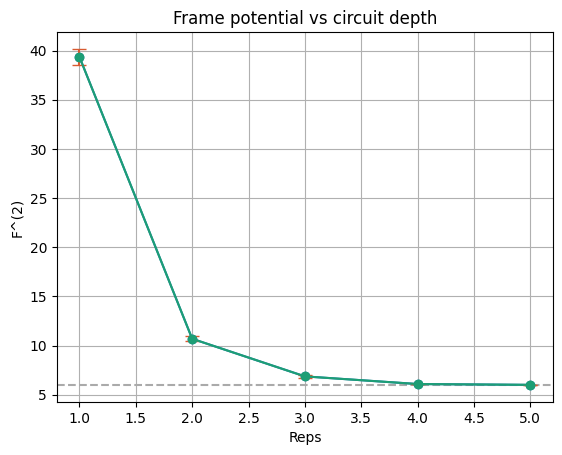

In [20]:
F_Haar = haar_frame_potential(3, 4)
plt.axhline(F_Haar, color='#aaaaaa', linestyle='--', label='Haar value')
plt.plot(range(1, len(F)+1), F, 'o-')
plt.errorbar(range(1, len(F)+1), F, yerr=errors, fmt='o-', capsize=5, color='#1d9e75', ecolor='#d85a30', label='Frame potential with error bars')
plt.xlabel("Reps")
plt.ylabel(f"F^({T_ORDER})")
plt.title("Frame potential vs circuit depth")
plt.grid(True)
plt.show()

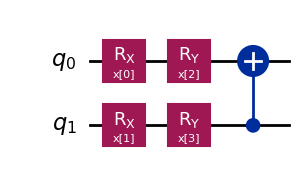

In [21]:
qc = SU2(reps=1)
qc.draw(output='mpl')

In [22]:
result = compute_frame_potential_gpu(
        qc,
        t         = 3,
        converge_before_return = True,
        dtype     = torch.complex64,
        seed      = SEED,
        verbose   = True,
    )

Convergence mode: will keep sampling until the fidelity error is below the threshold.
GPU found : Intel(R) Iris(R) Xe Graphics  (Intel XPU)
VRAM      : 28.7 GB
GPU found : Intel(R) Iris(R) Xe Graphics  (Intel XPU)
VRAM      : 28.7 GB
Auto batch size : 500  (VRAM=28.7GB, d=4)

n_qubits=2  d=4  N=500  t=3
dtype=torch.complex64  batch_size=500
──────────────────────────────────────────────────


Sampling on CPU: 100%|██████████| 500/500 [00:00<00:00, 2898.53it/s]

Transferring 0.1 MB to xpu ...
Computing frame potential on GPU ...

──────────────────────────────────────────────────
  F^(3) (ansatz)  : 39.356590
  F^(3) (Haar)    : 6.000000
  ΔF (gap)         : 33.356590
  Ratio F/F_Haar   : 6.5594
  ✗ Far from 3-design
──────────────────────────────────────────────────
Convergence check: error=0.812780, threshold=13.342636, samples=250000
